# Stage 3 — Symptomatic Subtype Classification

三分類：`upper_infection` vs `lower_infection` vs `obstructive_disease`

只在 Stage 2 判定為 `symptomatic` 時才執行。

特徵：516 維（512 HeAR + age + gender + respiratory + fever）

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report
from utils import plot_confusion_matrix

os.makedirs('checkpoints', exist_ok=True)

## Prepare Data

只使用 `symptomatic` 的樣本，並用 `expert_label` 做三分類。

In [2]:
EMB_COLS  = [f'emb_{i}' for i in range(512)]
CLIN_COLS = ['age', 'gender_encoded', 'respiratory_condition', 'fever_muscle_pain']
FEATURES  = EMB_COLS + CLIN_COLS

df = pd.read_csv('data/prepared_train_hear.csv')

# 只保留 symptomatic 樣本
df_s3 = df[df['label'] == 'symptomatic'].copy()

# 確認 expert_label 分佈
print('symptomatic 子類分佈:')
print(df_s3['expert_label'].value_counts())
print('總筆數:', len(df_s3))

X = np.array(df_s3[FEATURES], dtype=np.float32)
encoder = LabelEncoder()
y = encoder.fit_transform(df_s3['expert_label'])

print('\nclasses:', encoder.classes_)

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

symptomatic 子類分佈:
expert_label
upper_infection        227
lower_infection        167
obstructive_disease    159
Name: count, dtype: int64
總筆數: 553

classes: ['lower_infection' 'obstructive_disease' 'upper_infection']
X_train: (442, 516), X_test: (111, 516)


## 5-Fold Cross Validation

K-FOLD CROSS VALIDATION RESULTS FOR 5 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       69.23 % |       60.36 % |
| Fold 1  |       71.72 % |       58.56 % |
| Fold 2  |       70.59 % |       63.96 % |
| Fold 3  |       69.98 % |       59.09 % |
| Fold 4  |       69.30 % |       49.09 % |
--------------------------------------------
| Average |       70.16 % |       58.21 % |
| Std Dev |       0.92 % |       4.94 % |

                     precision    recall  f1-score   support

    lower_infection       0.44      0.45      0.44        38
obstructive_disease       0.68      0.58      0.62        33
    upper_infection       0.42      0.46      0.44        39

           accuracy                           0.49       110
          macro avg       0.51      0.49      0.50       110
       weighted avg       0.50      0.49      0.50       110



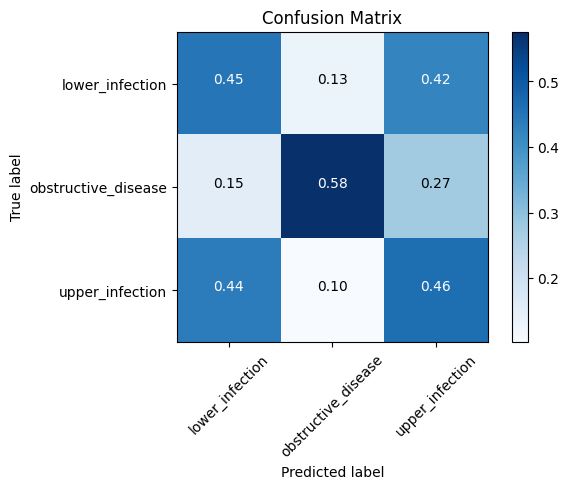

In [3]:
k_folds = 5
kfold   = KFold(n_splits=k_folds, shuffle=True, random_state=42)
results_train, results_test = [], []
last_preds, last_labels = None, None

print(f'K-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
print('--------------------------------------------')
print('|         | Train Accuracy | Test Accuracy |')
print('--------------------------------------------')

for fold, (tr_ids, te_ids) in enumerate(kfold.split(np.arange(len(y)))):
    X_tr = StandardScaler().fit_transform(X[tr_ids])
    X_te = StandardScaler().fit(X[tr_ids]).transform(X[te_ids])
    y_tr, y_te = y[tr_ids], y[te_ids]

    clf_tmp = LogisticRegression(C=0.001, max_iter=1000, random_state=42, class_weight='balanced')
    clf_tmp.fit(X_tr, y_tr)

    tr_acc = clf_tmp.score(X_tr, y_tr)
    te_acc = clf_tmp.score(X_te, y_te)
    results_train.append(tr_acc)
    results_test.append(te_acc)
    last_preds  = clf_tmp.predict(X_te)
    last_labels = y_te
    print(f'| Fold {fold}  |       {tr_acc*100:.2f} % |       {te_acc*100:.2f} % |')

print('--------------------------------------------')
print(f'| Average |       {np.mean(results_train)*100:.2f} % |       {np.mean(results_test)*100:.2f} % |')
print(f'| Std Dev |       {np.std(results_train)*100:.2f} % |       {np.std(results_test)*100:.2f} % |')
print()
print(classification_report(last_labels, last_preds, target_names=encoder.classes_))
plot_confusion_matrix(last_labels, last_preds, encoder.classes_)

## 訓練最終模型 & 儲存

Train Accuracy: 70.81 %
Test Accuracy:  57.66 %
                     precision    recall  f1-score   support

    lower_infection       0.45      0.55      0.49        33
obstructive_disease       0.71      0.75      0.73        32
    upper_infection       0.59      0.48      0.53        46

           accuracy                           0.58       111
          macro avg       0.58      0.59      0.58       111
       weighted avg       0.58      0.58      0.58       111

Saved: checkpoints/stage3_symptomatic_subtype.pkl


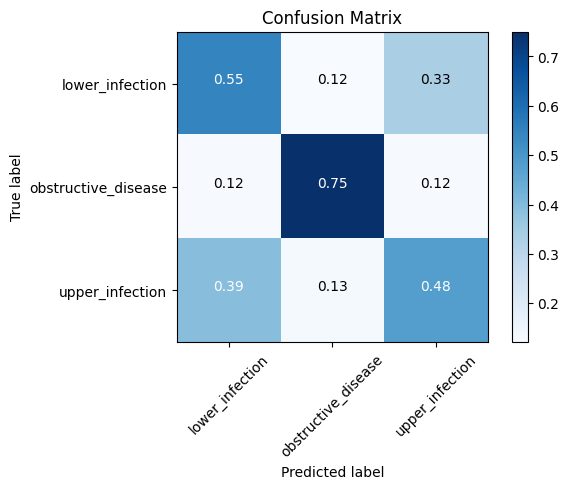

In [4]:
clf_s3 = LogisticRegression(C=0.001, max_iter=1000, random_state=42, class_weight='balanced')
clf_s3.fit(X_train, y_train)

train_acc = clf_s3.score(X_train, y_train)
test_acc  = clf_s3.score(X_test,  y_test)
print(f'Train Accuracy: {train_acc*100:.2f} %')
print(f'Test Accuracy:  {test_acc*100:.2f} %')

predictions = clf_s3.predict(X_test)
print(classification_report(y_test, predictions, target_names=encoder.classes_))
plot_confusion_matrix(y_test, predictions, encoder.classes_)

joblib.dump({
    'clf': clf_s3, 'scaler': scaler,
    'encoder': encoder, 'features': FEATURES
}, 'checkpoints/stage3_symptomatic_subtype.pkl')
print('Saved: checkpoints/stage3_symptomatic_subtype.pkl')